Diabetes Classification with K-Nearest Neighbors (KNN)
Jorge Angon, Aiden Gonzales

Kaggle: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score

# Read the csv file
df = pd.read_csv("diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [23]:
# Check the data types
df.dtypes

,0
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64


In [24]:
# Check the size of the dataset
df.shape

(768, 9)

In [25]:
# Check zero values in medical columns
zero_counts = pd.DataFrame({
    "Zero Count": (df[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']] == 0).sum()
})
zero_counts

,Zero Count
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11


In [26]:
# Clean the data by replacing 0 with the median
columns_with_zero_as_missing = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df[columns_with_zero_as_missing] = df[columns_with_zero_as_missing].replace(0, np.nan)

for col in columns_with_zero_as_missing:
    df[col] = df[col].fillna(df[col].median())

df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63,0
764,2,122.0,70.0,27.0,125.0,36.8,0.340,27,0
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30,0
766,1,126.0,60.0,29.0,125.0,30.1,0.349,47,1


In [27]:
# Make the target easier to read
df['Outcome_Label'] = df['Outcome'].map({0: 'No Diabetes', 1: 'Diabetes'})

df['Outcome_Label'].value_counts()

,count
Outcome_Label,
No Diabetes,500
Diabetes,268


In [28]:
# Look at the average values by class
df.groupby('Outcome_Label')[[
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age'
]].mean().round(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome_Label,,,,,,,,
Diabetes,4.87,142.13,75.12,31.69,164.70,35.38,0.55,37.07
No Diabetes,3.30,110.68,70.92,27.73,127.79,30.89,0.43,31.19


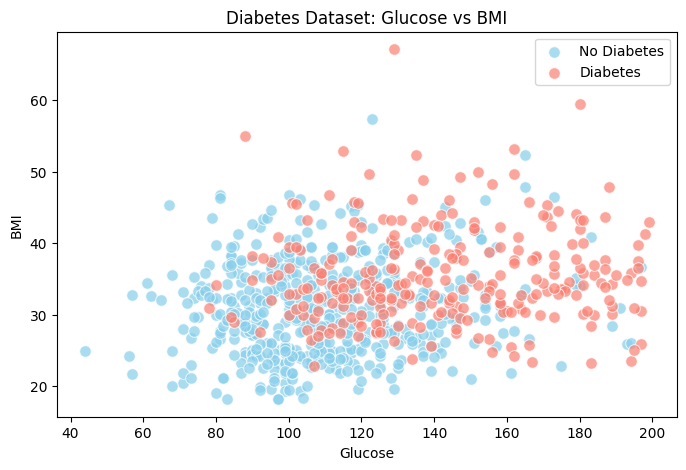

In [51]:
# Make a scatter plot
plt.figure(figsize=(8, 5))

colors = {'No Diabetes': 'skyblue', 'Diabetes': 'salmon'}

for label_name, color in colors.items():
    subset = df[df['Outcome_Label'] == label_name]
    plt.scatter(
        subset['Glucose'],
        subset['BMI'],
        c=color,
        label=label_name,
        alpha=0.7,
        s=70,
        edgecolors='white',
        linewidth=0.8
    )

plt.title('Diabetes Dataset: Glucose vs BMI')
plt.xlabel('Glucose')
plt.ylabel('BMI')
plt.legend()
plt.show()

In [32]:
# Split the dataset into x and y
# x is the input columns
# y is the answer column
x = df.drop(['Outcome', 'Outcome_Label'], axis=1).values
y = df['Outcome_Label'].values

In [33]:
# Split the data into training data and testing data
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

In [34]:
# Scale the data
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [35]:
# Train the first KNN model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)

KNeighborsClassifier()

In [36]:
# Make predictions using the test data
y_pred = knn.predict(x_test)
y_pred

array(['Diabetes', 'Diabetes', 'No Diabetes', 'No Diabetes',
       'No Diabetes', 'No Diabetes', 'Diabetes', 'No Diabetes',
       'No Diabetes', 'No Diabetes', 'No Diabetes', 'No Diabetes',
       'Diabetes', 'No Diabetes', 'No Diabetes', 'No Diabetes',
       'Diabetes', 'No Diabetes', 'Diabetes', 'No Diabetes', 'Diabetes',
       'No Diabetes', 'No Diabetes', 'No Diabetes', 'No Diabetes',
       'Diabetes', 'No Diabetes', 'No Diabetes', 'No Diabetes',
       'Diabetes', 'No Diabetes', 'No Diabetes', 'Diabetes',
       'No Diabetes', 'No Diabetes', 'No Diabetes', 'Diabetes',
       'Diabetes', 'No Diabetes', 'Diabetes', 'No Diabetes', 'Diabetes',
       'No Diabetes', 'No Diabetes', 'No Diabetes', 'No Diabetes',
       'No Diabetes', 'Diabetes', 'No Diabetes', 'No Diabetes',
       'Diabetes', 'No Diabetes', 'No Diabetes', 'Diabetes', 'Diabetes',
       'No Diabetes', 'No Diabetes', 'No Diabetes', 'No Diabetes',
       'Diabetes', 'No Diabetes', 'Diabetes', 'Diabetes', 'No Diabetes'

In [37]:
# Compare the real answers and predicted answers
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})
results

,Actual,Predicted
0,Diabetes,Diabetes
1,Diabetes,Diabetes
2,No Diabetes,No Diabetes
3,No Diabetes,No Diabetes
4,Diabetes,No Diabetes
...,...,...
149,Diabetes,Diabetes
150,No Diabetes,No Diabetes
151,No Diabetes,No Diabetes
152,No Diabetes,No Diabetes


In [38]:
# Check how well the model did
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label='Diabetes')
recall = recall_score(y_test, y_pred, pos_label='Diabetes')
f1 = f1_score(y_test, y_pred, pos_label='Diabetes')

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

Accuracy: 0.7467532467532467
Precision: 0.6666666666666666
Recall: 0.5555555555555556
F1 Score: 0.6060606060606061


In [40]:
# Show the classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Diabetes       0.67      0.56      0.61        54
 No Diabetes       0.78      0.85      0.81       100

    accuracy                           0.75       154
   macro avg       0.72      0.70      0.71       154
weighted avg       0.74      0.75      0.74       154



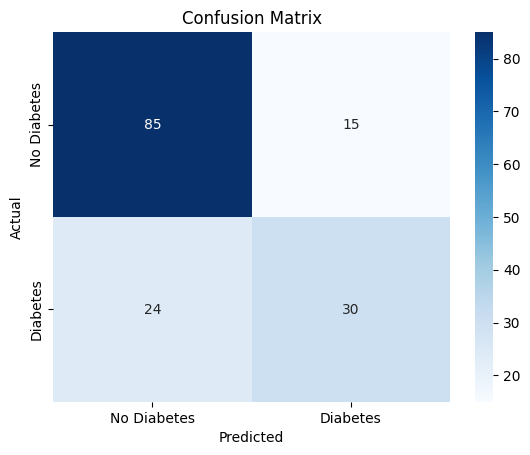

In [41]:
# Make the confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=['No Diabetes', 'Diabetes'])

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [49]:
# Test odd k values to find the best one
k_values = range(1, 32, 2)
cv_means = []
cv_stds = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(model, x_train, y_train, cv=5, scoring='accuracy')
    cv_means.append(scores.mean())
    cv_stds.append(scores.std())

best_k = list(k_values)[np.argmax(cv_means)]
best_k

25

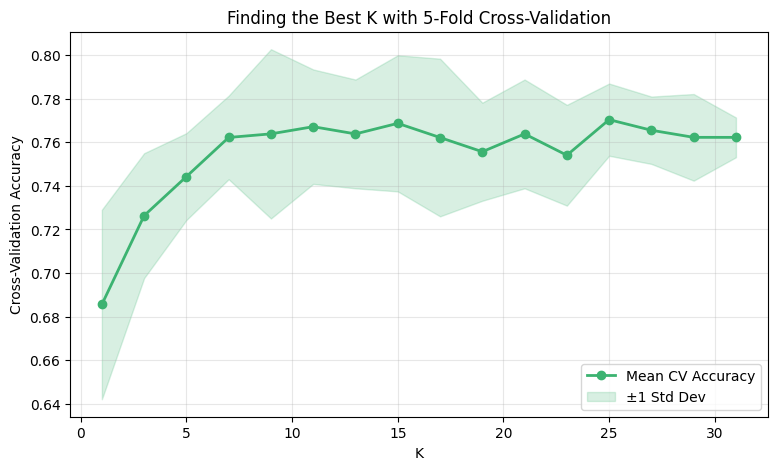

In [50]:
# Plot k and cross validation accuracy
plt.figure(figsize=(9, 5))

plt.plot(
    list(k_values),
    cv_means,
    marker='o',
    color='mediumseagreen',
    linewidth=2,
    label='Mean CV Accuracy'
)

plt.fill_between(
    list(k_values),
    np.array(cv_means) - np.array(cv_stds),
    np.array(cv_means) + np.array(cv_stds),
    color='mediumseagreen',
    alpha=0.2,
    label='±1 Std Dev'
)

plt.title('Finding the Best K with 5-Fold Cross-Validation')
plt.xlabel('K')
plt.ylabel('Cross-Validation Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [44]:
# Train the final model using the best k
final_model = KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(x_train, y_train)

final_pred = final_model.predict(x_test)

In [45]:
# Check the final model
final_accuracy = accuracy_score(y_test, final_pred)
final_precision = precision_score(y_test, final_pred, pos_label='Diabetes')
final_recall = recall_score(y_test, final_pred, pos_label='Diabetes')
final_f1 = f1_score(y_test, final_pred, pos_label='Diabetes')

print(f"Accuracy: {final_accuracy}")
print(f"Precision: {final_precision}")
print(f"Recall: {final_recall}")
print(f"F1 Score: {final_f1}")

Accuracy: 0.7402597402597403
Precision: 0.6590909090909091
Recall: 0.5370370370370371
F1 Score: 0.5918367346938775


In [52]:
# Lets us enter our own data
while True:
    try:
        pregnancies = float(input("Enter Pregnancies: "))
        glucose = float(input("Enter Glucose: "))
        blood_pressure = float(input("Enter BloodPressure: "))
        skin_thickness = float(input("Enter SkinThickness: "))
        insulin = float(input("Enter Insulin: "))
        bmi = float(input("Enter BMI: "))
        dpf = float(input("Enter DiabetesPedigreeFunction: "))
        age = float(input("Enter Age: "))

        new_data_point = np.array([[pregnancies, glucose, blood_pressure, skin_thickness, insulin, bmi, dpf, age]])
        new_data_point = scaler.transform(new_data_point)

        prediction = final_model.predict(new_data_point)
        probabilities = final_model.predict_proba(new_data_point)

        print(f"Predicted Result: {prediction[0]}")
        print("Confidence Scores:")

        for class_name, prob in zip(final_model.classes_, probabilities[0]):
            print(f"{class_name}: {prob}")

        break

    except ValueError:
        print("Invalid input. Please enter a valid number.")
    except Exception as e:
        print(f"An error occurred: {e}")

Enter Pregnancies: 4
Enter Glucose: 148
Enter BloodPressure: 72
Enter SkinThickness: 23
Enter Insulin: 168
Enter BMI: 33.7
Enter DiabetesPedigreeFunction: 0.627
Enter Age: 44
Predicted Result: Diabetes
Confidence Scores:
Diabetes: 0.6
No Diabetes: 0.4


For this model we predict whether a patient is likely to have diabetes based on health measurements like glucose, blood pressure, insulin,BMI, age, etc. The model first ran with k=5 and had a 74.68% accuracy and after testing multiple odd k values, the best k was 25. The final model with k=25 reached 74.032% accuracy, a 65.91% precision, a recall of 53.70%, and a F1 score of 59.18%. This means that the model did a ok job overall but it was better at identifying patients without diabetes than catching every patient with diabetes. When a sample patient was inputted, the model predicted diabetes with a 60% confidence. Overall, this model works as a helpful early prediction tool but it should be used as a support and not as a replacement due to the ok scores.